import pandas as pd → tablo/veri analizi için Pandas’ı açar.
import numpy as np → sayısal işlemler ve rastgele veri üretmek için.
matplotlib / seaborn → grafik çizmek için.
scipy → istatistiksel işlemler için.

np.random.seed(42) → her çalıştırmada aynı rastgele verilerin oluşmasını sağlar.

pd.set_option(...) → DataFrame ekranda daha okunaklı görünsün diye görüntü ayarlarını değiştirir.

pd.DataFrame({...}) → tablo oluşturur.

np.random.randint(...) → rastgele tam sayı üretir.

np.random.normal(...) → normal dağılıma yakın rastgele sayılar üretir.

np.random.choice(...) → verilen seçeneklerden rastgele seçim yapar.

pd.date_range(...) → tarih aralığı üretir.

np.nan → eksik değer oluşturur.

df.loc[...] → belirli satır/sütunlara erişip değer değiştirmek için kullanılır.

pd.concat(...) → DataFrame'leri birleştirir; burada duplicate satır eklemek için kullandık.

df.shape → satır ve sütun sayısını verir.

df.info() → sütun tiplerini, dolu/boş değerleri gösterir.

df.head() → ilk satırları gösterir.

df.tail() → son satırları gösterir.

df.sample() → rastgele satırlar gösterir.

df.isnull() → hangi hücrelerin boş olduğunu kontrol eder.

df.isnull().sum() → her sütundaki boş değer sayısını verir.

df.nunique() → her sütunda kaç farklı değer olduğunu gösterir.

df.duplicated() → aynı olan satırları bulur.

value_counts() → bir değerin kaç kez geçtiğini gösterir.

str.strip() → baştaki ve sondaki boşlukları siler.

str.lower() → yazıları küçük harfe çevirir.

str.title() → kelimelerin ilk harfini büyütür.

df.describe() → ortalama, standart sapma, min, max, çeyrekler gibi istatistikleri verir.

median() → ortanca değeri bulur.

skew() → dağılımın sağa mı sola mı çarpık olduğunu ölçer.

kurtosis() → dağılımın sivriliğini/basıklığını ölçer.

sns.histplot(..., kde=True) → verinin dağılımını histogram ve eğriyle gösterir.

sns.boxplot() → aykırı değerleri görmeyi kolaylaştıran kutu grafiğidir.

select_dtypes(include=np.number) → sadece sayısal sütunları seçer.

corr() → değişkenlerin birbirleriyle ne kadar ilişkili olduğunu hesaplar. Değer genellikle -1 ile +1 arasındadır.

sns.heatmap() → matrisi renkli tablo şeklinde gösterir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid") #sns.set_theme(style=whitegrid)
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [ ]:
n = 1000

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),
    "yas": np.random.normal(38, 12, n).round(0),
    "gelir": np.random.lognormal(mean=10.5, sigma=0.6, size=n).round(2),
    "sehir": np.random.choice(
        ["İstanbul", "Ankara", "İzmir", "Bursa", "istanbul", "ANKARA"],  # kasıtlı tutarsız yazım
        size=n, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.35, 0.15]),
    "kayit_tarihi": pd.date_range("2022-01-01", periods=n, freq="7h"),
    "aylik_harcama": np.random.gamma(shape=2, scale=150, size=n).round(2),
    "memnuniyet_puani": np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.1, 0.2, 0.35, 0.3]),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
})

In [ ]:
df.loc[df.sample(frac=0.08, random_state=1).index, "gelir"] = np.nan
df.loc[df.sample(frac=0.05, random_state=2).index, "yas"] = np.nan
df.loc[df.sample(frac=0.03, random_state=3).index, "memnuniyet_puani"] = np.nan
outlier_idx = df.sample(frac=0.01, random_state=4).index
df.loc[outlier_idx, "gelir"] = df["gelir"].max() * np.random.uniform(3, 6, len(outlier_idx))
df.loc[df.sample(frac=0.005, random_state=5).index, "yas"] = -5
df.loc[df.sample(frac=0.005, random_state=6).index, "yas"] = 150
df = pd.concat([df, df.sample(5, random_state=7)], ignore_index=True)

In [ ]:
print(f"Veri Seti :{df.shape[0]} satır, {df.shape[1]} sütun")

Veri Seti :1005 satır, 9 sütun


In [ ]:
df.shape

(1005, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1005 non-null   int64         
 1   yas               956 non-null    float64       
 2   gelir             926 non-null    float64       
 3   sehir             1005 non-null   object        
 4   abonelik_tipi     1005 non-null   object        
 5   kayit_tarihi      1005 non-null   datetime64[ns]
 6   aylik_harcama     1005 non-null   float64       
 7   memnuniyet_puani  975 non-null    float64       
 8   churn             1005 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 70.8+ KB


In [ ]:
df.head()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1,44.00,84087.51,Ankara,Temel,2022-01-01 00:00:00,519.21,4.00,0
1,2,36.00,63245.56,İstanbul,Standart,2022-01-01 07:00:00,386.18,2.00,0
2,3,46.00,37638.33,İstanbul,Standart,2022-01-01 14:00:00,1014.04,5.00,0
3,4,56.00,24632.89,İstanbul,Temel,2022-01-01 21:00:00,59.01,5.00,0
4,5,35.00,55211.91,istanbul,Standart,2022-01-02 04:00:00,104.91,2.00,0


In [ ]:
df.tail()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1000,779,37.00,28068.93,istanbul,Temel,2022-08-15 22:00:00,420.46,4.00,0
1001,335,50.00,39703.73,İstanbul,Premium,2022-04-08 10:00:00,272.02,3.00,0
1002,272,21.00,52338.26,Ankara,Temel,2022-03-21 01:00:00,456.14,3.00,0
1003,803,39.00,23740.93,İstanbul,Standart,2022-08-22 22:00:00,520.06,4.00,0
1004,217,29.00,24243.54,İstanbul,Temel,2022-03-05 00:00:00,838.08,3.00,0


In [ ]:
df.sample(5, random_state=1)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
685,686,47.00,NaN,İstanbul,Premium,2022-07-19 19:00:00,390.24,3.00,0
614,615,67.00,NaN,İstanbul,Standart,2022-06-29 02:00:00,149.73,4.00,0
602,603,48.00,24647.27,İzmir,Temel,2022-06-25 14:00:00,234.32,4.00,1
502,503,21.00,NaN,İstanbul,Premium,2022-05-27 10:00:00,400.23,4.00,0
341,342,41.00,36381.93,istanbul,Temel,2022-04-10 11:00:00,35.14,4.00,0


In [ ]:
print("\n ---- Sütun Özeti----")
ozet= pd.DataFrame({
    "dtype":df.dtypes,
    "eksik_deger":df.isnull().sum(),
    "unique_deger":df.nunique(),
    "eksik_deger_yuzdesi":(df.isnull().mean()*100).round(2),
})


 ---- Sütun Özeti----


In [ ]:
print(ozet)

                           dtype  eksik_deger  unique_deger  \
musteri_id                 int64            0          1000   
yas                      float64           49            70   
gelir                    float64           79           921   
sehir                     object            0             6   
abonelik_tipi             object            0             3   
kayit_tarihi      datetime64[ns]            0          1000   
aylik_harcama            float64            0           995   
memnuniyet_puani         float64           30             5   
churn                      int64            0             2   

                  eksik_deger_yuzdesi  
musteri_id                       0.00  
yas                              4.88  
gelir                            7.86  
sehir                            0.00  
abonelik_tipi                    0.00  
kayit_tarihi                     0.00  
aylik_harcama                    0.00  
memnuniyet_puani                 2.99  
churn    

In [ ]:
eksik =df.isnull().sum()

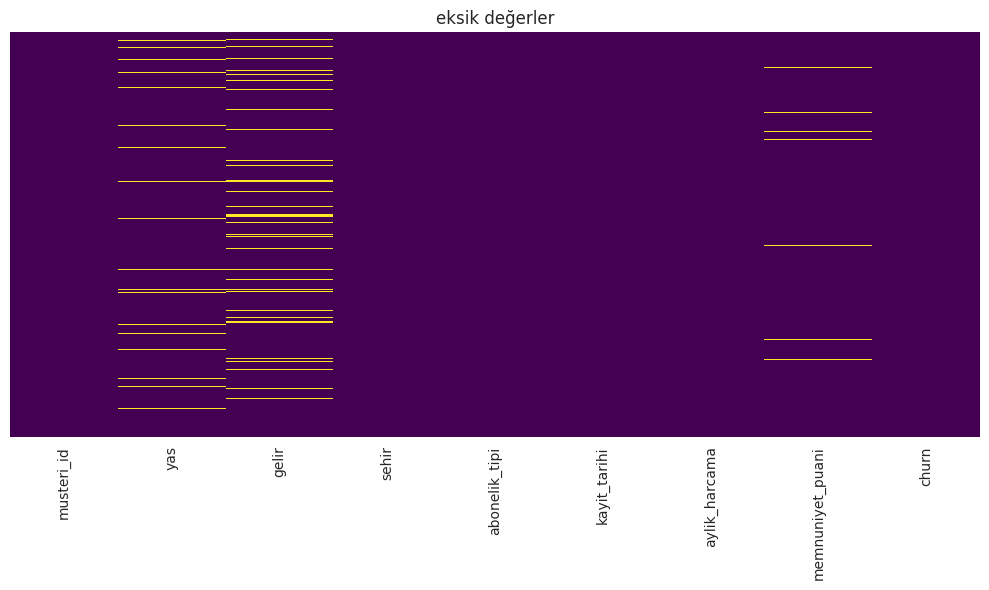

In [ ]:
#eksik değerleri görselleştirelim
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("eksik değerler")
plt.tight_layout()
plt.savefig("eksik_degerler.png", dpi=300)
plt.show()

In [ ]:
n_dup = df.duplicated().sum()

In [ ]:
n_dup

np.int64(5)

In [ ]:
print(df["sehir"].value_counts())

sehir
İstanbul    361
Ankara      190
İzmir       150
Bursa       109
istanbul    101
ANKARA       94
Name: count, dtype: int64


In [ ]:
df["sehir"] = df["sehir"].str.lower().str.strip()

In [ ]:
df["sehir"] = df["sehir"].str.replace('i',"i").str.replace("ı","ı")

In [ ]:
print(df[(df["yas"]< 0)|(df["yas"]>100)][["musteri_id","yas"]])

     musteri_id    yas
11           12  -5.00
22           23 150.00
193         194  -5.00
262         263  -1.00
279         280  -5.00
399         400 150.00
438         439 150.00
515         516  -5.00
544         545  -5.00
909         910 150.00
978         979 150.00


In [ ]:
df.describe()

,musteri_id,yas,gelir,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
count,1005.00,956.00,926.00,1005,1005.00,975.00,1005.00
mean,500.40,38.61,57050.67,2022-05-26 15:49:40.298507520,296.50,3.69,0.18
min,1.00,-5.00,6292.98,2022-01-01 00:00:00,4.54,1.00,0.00
25%,251.00,30.00,25195.60,2022-03-14 22:00:00,148.91,3.00,0.00
50%,500.00,38.00,38028.92,2022-05-26 13:00:00,251.53,4.00,0.00
75%,751.00,46.00,56173.36,2022-08-07 18:00:00,402.07,5.00,0.00
max,1000.00,150.00,1377244.81,2022-10-19 09:00:00,1550.69,5.00,1.00
std,288.67,14.47,120750.24,NaN,205.66,1.12,0.39


In [ ]:
print("\n ---- Çapıklık/BAsıklık----")

sayisal_sutunlar =df.select_dtypes(include=[np.number]).columns.tolist()
sayisal_sutunlar.remove("musteri_id")

for col in sayisal_sutunlar:
  print(f"skew: {df[col].skew():.2f} kurt: {df[col].kurt():.2f}")


 ---- Çapıklık/BAsıklık----
skew: 2.28 kurt: 17.21
skew: 8.95 kurt: 83.96
skew: 1.43 kurt: 3.40
skew: -0.73 kurt: -0.15
skew: 1.63 kurt: 0.67


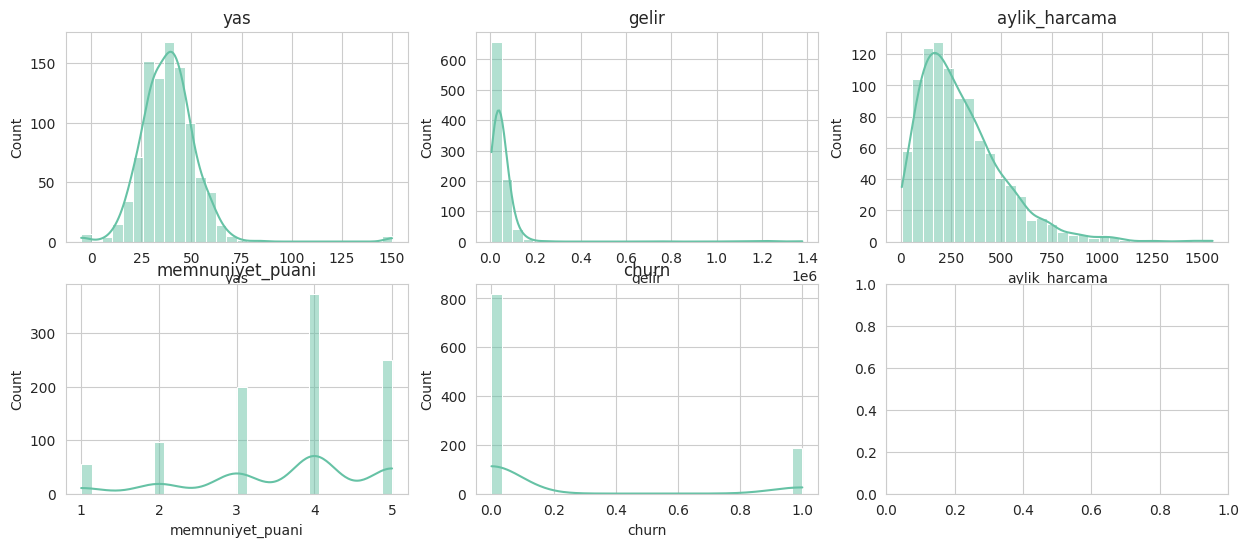

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.histplot(df[col], ax=ax, kde=True,bins =30)
  ax.set_title(col)
plt.tight_layout
plt.savefig("histogramlar.png",dpi = 300)
plt.show ()

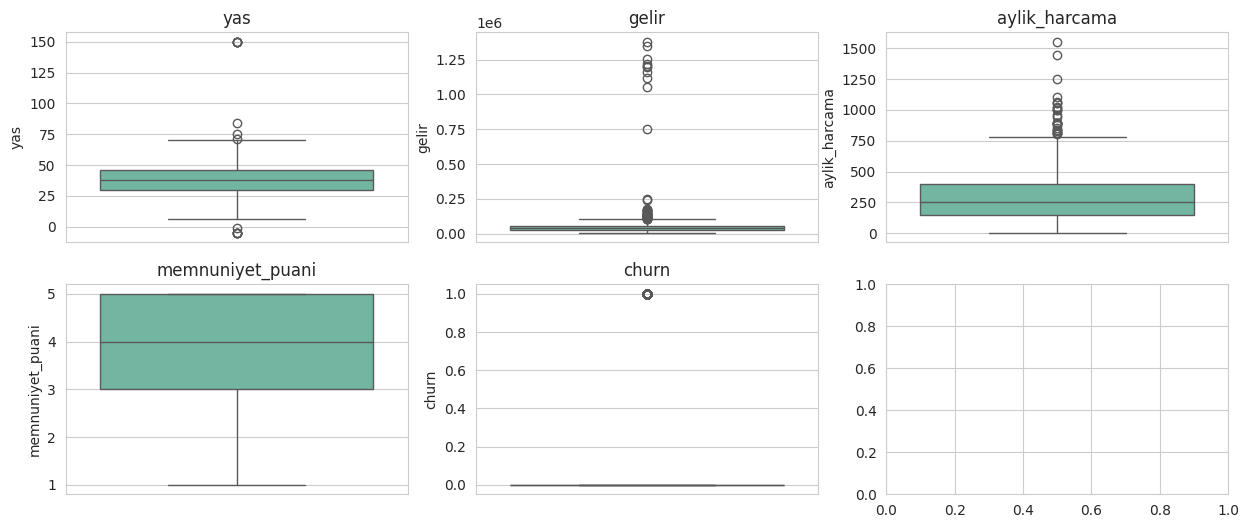

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.boxplot(y=df[col], ax=ax)
  ax.set_title(col)
plt.tight_layout
plt.savefig("boxplot.png",dpi = 300)
plt.show ()

In [ ]:
kategorik_sutünlar = ["sehir","abonelik_tipi","memnuniyet_puani","churn"]
for col in kategorik_sutünlar:

  print((df[col].value_counts(dropna=False, normalize=True)*100).round(2))

sehir
i̇stanbul   35.92
ankara      28.26
i̇zmir      14.93
bursa       10.85
istanbul    10.05
Name: proportion, dtype: float64
abonelik_tipi
Temel      51.74
Standart   35.92
Premium    12.34
Name: proportion, dtype: float64
memnuniyet_puani
4.00   37.21
5.00   24.88
3.00   19.90
2.00    9.55
1.00    5.47
NaN     2.99
Name: proportion, dtype: float64
churn
0   81.59
1   18.41
Name: proportion, dtype: float64


In [ ]:
korelasyon = df[sayisal_sutunlar].corr(numeric_only=True)
print("------ Korelasyon Matrisi-----")
print(korelasyon.round(2))

------ Korelasyon Matrisi-----
                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00   0.02          -0.00              0.04  -0.07
gelir             0.02   1.00          -0.04              0.01  -0.04
aylik_harcama    -0.00  -0.04           1.00              0.07  -0.02
memnuniyet_puani  0.04   0.01           0.07              1.00  -0.02
churn            -0.07  -0.04          -0.02             -0.02   1.00


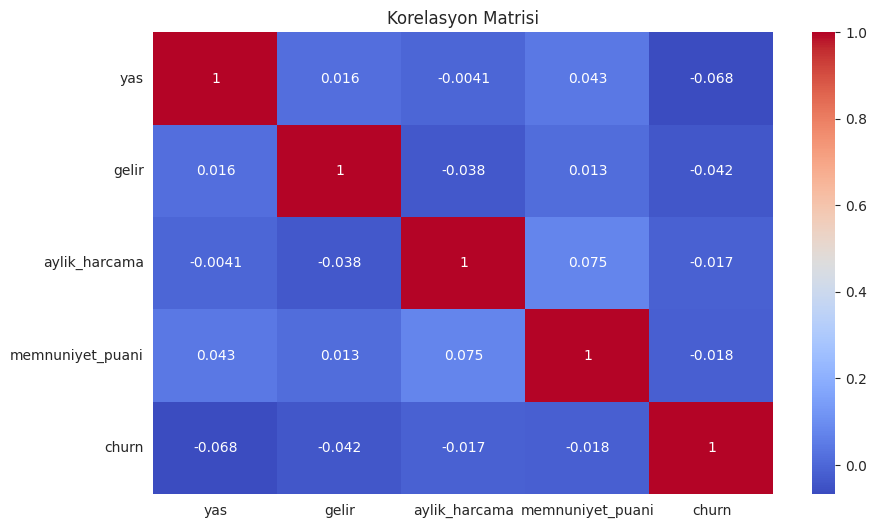

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.tight_layout
plt.savefig("korelasyon_matrisi.png", dpi=300)
plt.show()



```
1. Hazırlık ve Ortam Ayarları

Analiz için gerekli kütüphaneler (pandas, numpy, matplotlib, seaborn, scipy) nasıl içe aktarılır?
Grafiklerin görsel stili (tema, renk paleti, boyut) nasıl standart hale getirilir?
Sonuçların tekrarlanabilir olması için rastgelelik nasıl sabitlenir (random\_state/seed)?
Pandas'ta tüm sütun/satırların ve ondalık sayıların okunabilir biçimde görüntülenmesi nasıl sağlanır?

2. Örnek (Sentetik) Veri Setinin Oluşturulması

1000 müşteriden oluşan örnek bir veri seti (yaş, gelir, şehir, abonelik tipi, kayıt tarihi, aylık harcama, memnuniyet puanı, churn) nasıl üretilir?
Gerçek dünya verilerindeki tutarsızlıkları simüle etmek için şehir isimlerinde kasıtlı yazım farklılıkları (İstanbul/istanbul, Ankara/ANKARA) nasıl eklenir?

3. Kasıtlı "Kirli Veri" Enjeksiyonu

Veri setine eksik değerler (gelir, yaş, memnuniyet puanı sütunlarında) nasıl eklenir?
Gelir sütununda aşırı uç değerler (outlier) nasıl oluşturulur?
Yaş sütununa mantıksız değerler (-5, 150 gibi) nasıl eklenir?
Veri setine kasıtlı olarak yinelenen (duplicate) satırlar nasıl eklenir?

4. Veri Setine Genel Bakış

Veri setinin kaç satır ve kaç sütundan oluştuğu nasıl kontrol edilir?
Sütunların veri tipleri ve dolu/boş hücre sayıları (.info()) nasıl incelenir?
Veri setinin ilk, son ve rastgele seçilmiş birkaç satırı nasıl görüntülenir?

5. Eksik Değer Analizi

Her sütundaki eksik değer sayısı, benzersiz değer sayısı ve eksik değer yüzdesini gösteren bir özet tablo nasıl oluşturulur?
Eksik değerlerin veri setindeki dağılımı bir ısı haritası (heatmap) ile nasıl görselleştirilir?

6. Yinelenen Kayıtların Tespiti

Veri setinde kaç adet birebir aynı (duplicate) satır bulunduğu nasıl tespit edilir?

7. Kategorik Veri Temizliği

"Şehir" sütunundaki tutarsız yazımların (büyük/küçük harf, baştaki/sondaki boşluklar) dağılımı nasıl görüntülenir?
Şehir isimleri küçük harfe çevrilip boşluklardan nasıl arındırılır?

8. Mantık Dışı (Anomali) Değerlerin Tespiti

0'ın altında veya 100'ün üzerinde olan, gerçekçi olmayan yaş değerlerine sahip müşteriler nasıl bulunur?

9. Betimsel İstatistikler

Sayısal sütunların temel istatistiksel özeti (ortalama, medyan, std, min/max vb.) nasıl elde edilir?
Sayısal değişkenlerin çarpıklık (skewness) ve basıklık (kurtosis) değerleri nasıl hesaplanır?

10. Dağılım Görselleştirmeleri

Sayısal değişkenlerin dağılımları histogram ve yoğunluk eğrisi (KDE) ile nasıl gösterilir?
Sayısal değişkenlerdeki aykırı değerler kutu grafiği (boxplot) ile nasıl görselleştirilir?

11. Kategorik Değişken Analizi

Kategorik sütunların (şehir, abonelik tipi, memnuniyet puanı, churn) yüzdesel dağılımı nasıl hesaplanır?

12. Korelasyon Analizi

Sayısal değişkenler arasındaki korelasyon matrisi nasıl hesaplanır?
Korelasyon matrisi bir ısı haritası ile nasıl görselleştirilir?

```



In [ ]:
#Hazırlık ve Ortam Ayarları
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Görsel stil
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

# Rastgeleliği sabitle
np.random.seed(42)

# Pandas görüntü ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [ ]:
#Sentetik Veri Seti Oluşturma
n = 1000

sehirler = ["İstanbul", "istanbul", " Ankara", "ANKARA", "İzmir", "Bursa"]
abonelikler = ["Basic", "Premium", "Pro"]

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),

    "yas": np.random.randint(18, 70, n),

    "gelir": np.random.normal(40000, 12000, n),

    "sehir": np.random.choice(sehirler, n),

    "abonelik_tipi": np.random.choice(
        abonelikler,
        n,
        p=[0.5, 0.3, 0.2]
    ),

    "kayit_tarihi": pd.to_datetime(
        np.random.choice(
            pd.date_range("2022-01-01", "2026-01-01"),
            n
        )
    ),

    "aylik_harcama": np.random.normal(2500, 800, n),

    "memnuniyet_puani": np.random.randint(1, 6, n),

    "churn": np.random.choice(
        ["Evet", "Hayır"],
        n,
        p=[0.25, 0.75]
    )
})

print(df.head())

   musteri_id  yas    gelir     sehir abonelik_tipi kayit_tarihi  \
0           1   56 20722.64     İzmir           Pro   2023-06-14   
1           2   69 42441.56  istanbul         Basic   2025-10-26   
2           3   46 30923.79    ANKARA         Basic   2024-08-29   
3           4   32 22932.96     İzmir         Basic   2024-07-24   
4           5   60 32241.13    ANKARA         Basic   2025-11-23   

   aylik_harcama  memnuniyet_puani  churn  
0        2044.28                 2   Evet  
1        1887.05                 5  Hayır  
2        1702.55                 3   Evet  
3        2551.81                 5   Evet  
4        2178.41                 4  Hayır  


In [ ]:
##Kirli Veri Enjeksiyonu

# Eksik değerler
df.loc[np.random.choice(df.index, 50, replace=False), "gelir"] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), "yas"] = np.nan
df.loc[np.random.choice(df.index, 40, replace=False), "memnuniyet_puani"] = np.nan

# Gelir outlier
outlier_index = np.random.choice(df.index, 10, replace=False)
df.loc[outlier_index, "gelir"] = np.random.randint(200000, 500000, 10)

# Mantıksız yaşlar
df.loc[0, "yas"] = -5
df.loc[1, "yas"] = 150

# Duplicate satırlar
duplicate_rows = df.sample(10, random_state=42)

df = pd.concat(
    [df, duplicate_rows],
    ignore_index=True
)

print(df.shape)

(1010, 9)


In [ ]:
print("Satır - Sütun:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nİlk 5:")
print(df.head())

print("\nSon 5:")
print(df.tail())

print("\nRastgele 5:")
print(df.sample(5, random_state=42))

Satır - Sütun:
(1010, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1010 non-null   int64         
 1   yas               980 non-null    float64       
 2   gelir             960 non-null    float64       
 3   sehir             1010 non-null   object        
 4   abonelik_tipi     1010 non-null   object        
 5   kayit_tarihi      1010 non-null   datetime64[ns]
 6   aylik_harcama     1010 non-null   float64       
 7   memnuniyet_puani  970 non-null    float64       
 8   churn             1010 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 71.1+ KB

İlk 5:
   musteri_id    yas    gelir     sehir abonelik_tipi kayit_tarihi  \
0           1  -5.00 20722.64     İzmir           Pro   2023-06-14   
1           2 150.00 42441.56  istanbu

In [ ]:
#Eksik Değer Analizi
eksik_ozet = pd.DataFrame({
    "eksik_sayisi": df.isnull().sum(),
    "benzersiz_deger": df.nunique(),
    "eksik_yuzdesi": (df.isnull().sum() / len(df)) * 100
})

print(eksik_ozet)

                  eksik_sayisi  benzersiz_deger  eksik_yuzdesi
musteri_id                   0             1000           0.00
yas                         30               54           2.97
gelir                       50              950           4.95
sehir                        0                6           0.00
abonelik_tipi                0                3           0.00
kayit_tarihi                 0              724           0.00
aylik_harcama                0             1000           0.00
memnuniyet_puani            40                5           3.96
churn                        0                2           0.00


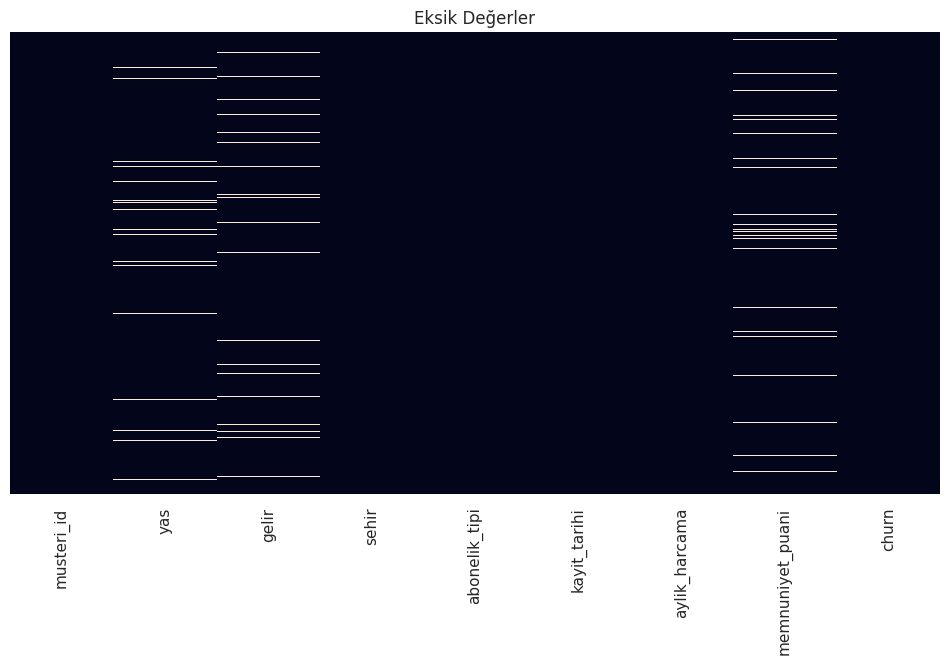

In [ ]:
#Heatmap:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Eksik Değerler")
plt.show()

In [ ]:
duplicate_sayisi = df.duplicated().sum()

print("Duplicate satır sayısı:", duplicate_sayisi)
print(df[df.duplicated()])

Duplicate satır sayısı: 10
      musteri_id   yas     gelir     sehir abonelik_tipi kayit_tarihi  \
1000         522 22.00  32236.76    ANKARA         Basic   2025-06-10   
1001         738 49.00  65741.79    ANKARA         Basic   2022-01-30   
1002         741 38.00 463272.00  İstanbul       Premium   2024-02-17   
1003         661 56.00  38199.33    Ankara         Basic   2024-10-29   
1004         412 59.00  54031.55     İzmir       Premium   2024-09-30   
1005         679 34.00  10007.13    Ankara       Premium   2023-01-19   
1006         627 58.00  32514.77     İzmir       Premium   2022-01-27   
1007         514 31.00  36626.80    Ankara         Basic   2025-11-17   
1008         860 43.00  40036.55  İstanbul         Basic   2023-05-23   
1009         137 44.00  45772.11     Bursa       Premium   2023-07-19   

      aylik_harcama  memnuniyet_puani  churn  
1000        2834.48              3.00  Hayır  
1001        2201.94              4.00  Hayır  
1002        3657.61         

In [ ]:
print(df["sehir"].value_counts())

sehir
ANKARA      184
 Ankara     178
Bursa       170
İzmir       170
İstanbul    167
istanbul    141
Name: count, dtype: int64


In [ ]:
#Temizleme:
df["sehir"] = (
    df["sehir"]
    .str.strip()
    .str.lower()
)

print(df["sehir"].value_counts())

sehir
ankara       362
i̇zmir       170
bursa        170
i̇stanbul    167
istanbul     141
Name: count, dtype: int64


In [ ]:
df["sehir"] = df["sehir"].str.title()

print(df["sehir"].value_counts())

sehir
Ankara       362
İZmir       170
Bursa        170
İStanbul    167
Istanbul     141
Name: count, dtype: int64


In [ ]:
#Mantık Dışı Yaşları Bulma
anormal_yaslar = df[
    (df["yas"] < 0) |
    (df["yas"] > 100)
]

print(anormal_yaslar)

   musteri_id    yas    gelir     sehir abonelik_tipi kayit_tarihi  \
0           1  -5.00 20722.64    İZmir           Pro   2023-06-14   
1           2 150.00 42441.56  Istanbul         Basic   2025-10-26   

   aylik_harcama  memnuniyet_puani  churn  
0        2044.28              2.00   Evet  
1        1887.05              5.00  Hayır  


In [ ]:
print(df.describe())

       musteri_id    yas     gelir                   kayit_tarihi  \
count     1010.00 980.00    960.00                           1010   
mean       501.38  43.87  44507.98  2024-01-04 16:40:52.277227776   
min          1.00  -5.00   5244.94            2022-01-04 00:00:00   
25%        252.25  31.00  32747.29            2023-01-12 06:00:00   
50%        503.50  44.00  40816.24            2024-01-09 00:00:00   
75%        748.75  56.00  48635.60            2025-01-02 12:00:00   
max       1000.00 150.00 483869.00            2026-01-01 00:00:00   
std        288.17  15.40  38055.86                            NaN   

       aylik_harcama  memnuniyet_puani  
count        1010.00            970.00  
mean         2453.42              2.95  
min          -171.60              1.00  
25%          1888.80              2.00  
50%          2462.25              3.00  
75%          3025.97              4.00  
max          4974.11              5.00  
std           804.14              1.40  


In [ ]:
print(df.select_dtypes(include=np.number).median())

musteri_id           503.50
yas                   44.00
gelir              40816.24
aylik_harcama       2462.25
memnuniyet_puani       3.00
dtype: float64


In [ ]:
print("Çarpıklık:")

print(
    df.select_dtypes(include=np.number).skew()
)

Çarpıklık:
musteri_id         -0.01
yas                 0.25
gelir               8.68
aylik_harcama      -0.01
memnuniyet_puani    0.08
dtype: float64


In [ ]:
print("Basıklık:")

print(
    df.select_dtypes(include=np.number).kurtosis()
)

Basıklık:
musteri_id         -1.20
yas                 1.08
gelir              85.85
aylik_harcama      -0.08
memnuniyet_puani   -1.28
dtype: float64


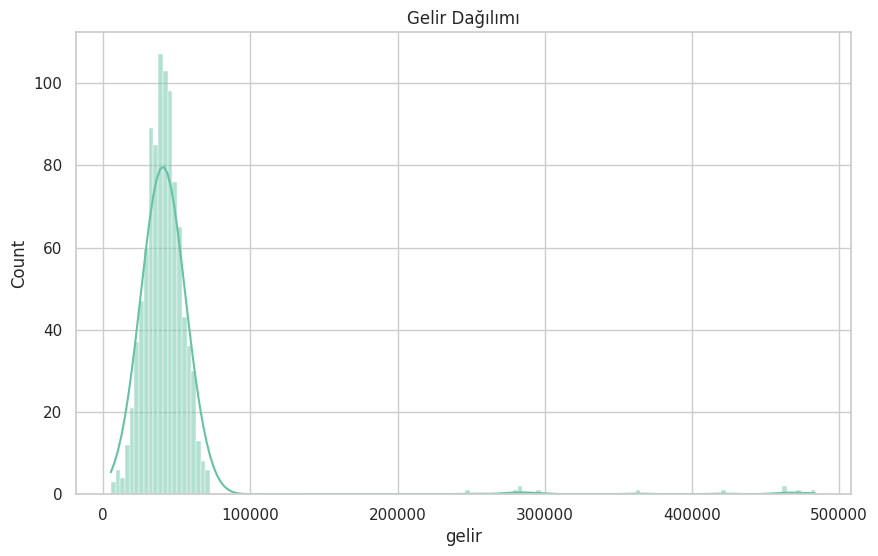

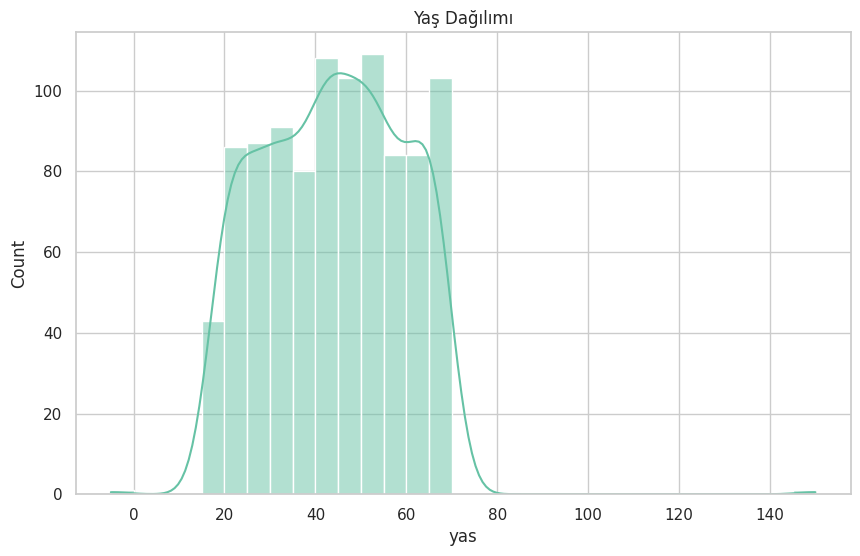

In [ ]:
#Histogram + KDE

sns.histplot(
    data=df,
    x="gelir",
    kde=True
)

plt.title("Gelir Dağılımı")
plt.show()

sns.histplot(
    data=df,
    x="yas",
    kde=True
)

plt.title("Yaş Dağılımı")
plt.show()



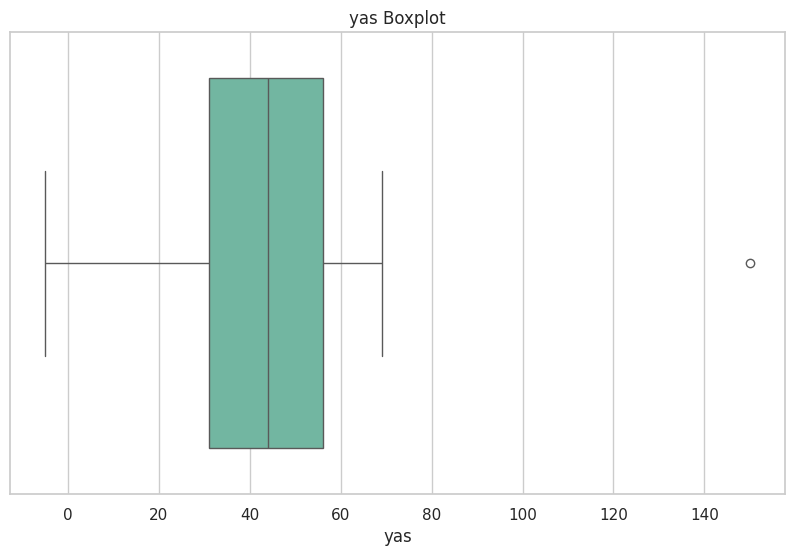

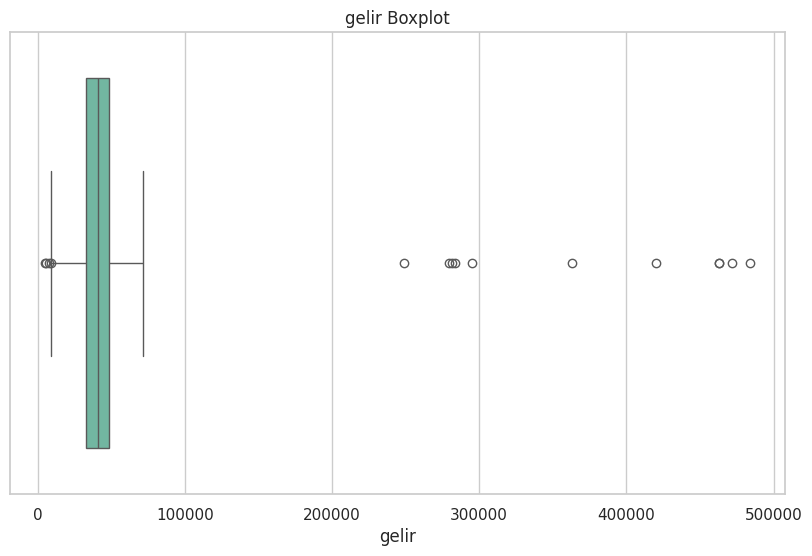

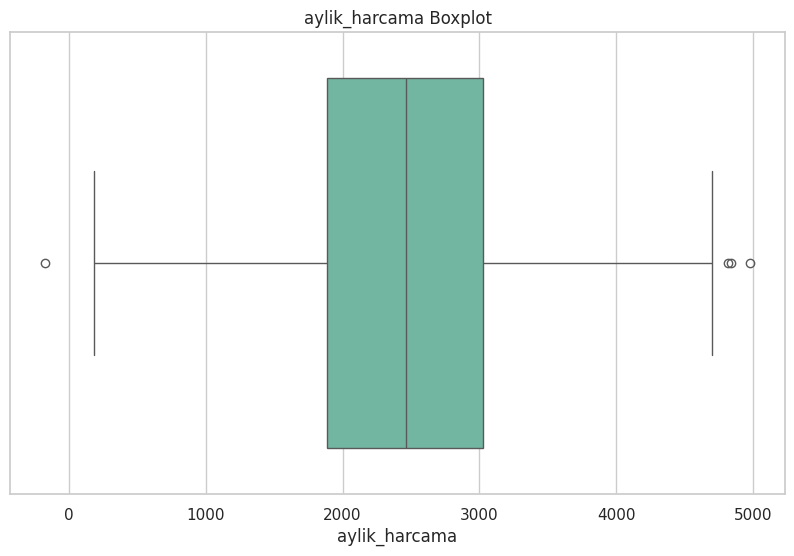

In [ ]:
#Kategori değişken analizi
sayisal = ["yas", "gelir", "aylik_harcama"]

for sutun in sayisal:

    sns.boxplot(
        data=df,
        x=sutun
    )

    plt.title(f"{sutun} Boxplot")
    plt.show()

In [ ]:
#şehir yüzdeleri
print(
    df["sehir"].value_counts(normalize=True) * 100
)

#abonelik
print(
    df["abonelik_tipi"].value_counts(normalize=True) * 100
)

#memnuniyet
print(
    df["memnuniyet_puani"].value_counts(normalize=True) * 100
)
#churn
print(
    df["churn"].value_counts(normalize=True) * 100
)


sehir
Ankara      35.84
İZmir      16.83
Bursa       16.83
İStanbul   16.53
Istanbul    13.96
Name: proportion, dtype: float64
abonelik_tipi
Basic     47.33
Premium   31.98
Pro       20.69
Name: proportion, dtype: float64
memnuniyet_puani
2.00   22.58
3.00   20.10
1.00   19.69
5.00   19.28
4.00   18.35
Name: proportion, dtype: float64
churn
Hayır   74.26
Evet    25.74
Name: proportion, dtype: float64


In [ ]:
#hepsini tek seferde

kategorik_sutunlar = [
    "sehir",
    "abonelik_tipi",
    "memnuniyet_puani",
    "churn"
]

for sutun in kategorik_sutunlar:

    print("\n", sutun.upper())

    print(
        df[sutun].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )


 SEHIR
sehir
Ankara      35.84
İZmir      16.83
Bursa       16.83
İStanbul   16.53
Istanbul    13.96
Name: proportion, dtype: float64

 ABONELIK_TIPI
abonelik_tipi
Basic     47.33
Premium   31.98
Pro       20.69
Name: proportion, dtype: float64

 MEMNUNIYET_PUANI
memnuniyet_puani
2.00   21.68
3.00   19.31
1.00   18.91
5.00   18.51
4.00   17.62
NaN     3.96
Name: proportion, dtype: float64

 CHURN
churn
Hayır   74.26
Evet    25.74
Name: proportion, dtype: float64


In [ ]:
#korelasyon analizi

sayisal_df = df.select_dtypes(include=np.number)

korelasyon = sayisal_df.corr()

print(korelasyon)

                  musteri_id   yas  gelir  aylik_harcama  memnuniyet_puani
musteri_id              1.00 -0.02   0.02           0.03             -0.02
yas                    -0.02  1.00   0.06          -0.01              0.04
gelir                   0.02  0.06   1.00           0.03              0.00
aylik_harcama           0.03 -0.01   0.03           1.00             -0.03
memnuniyet_puani       -0.02  0.04   0.00          -0.03              1.00


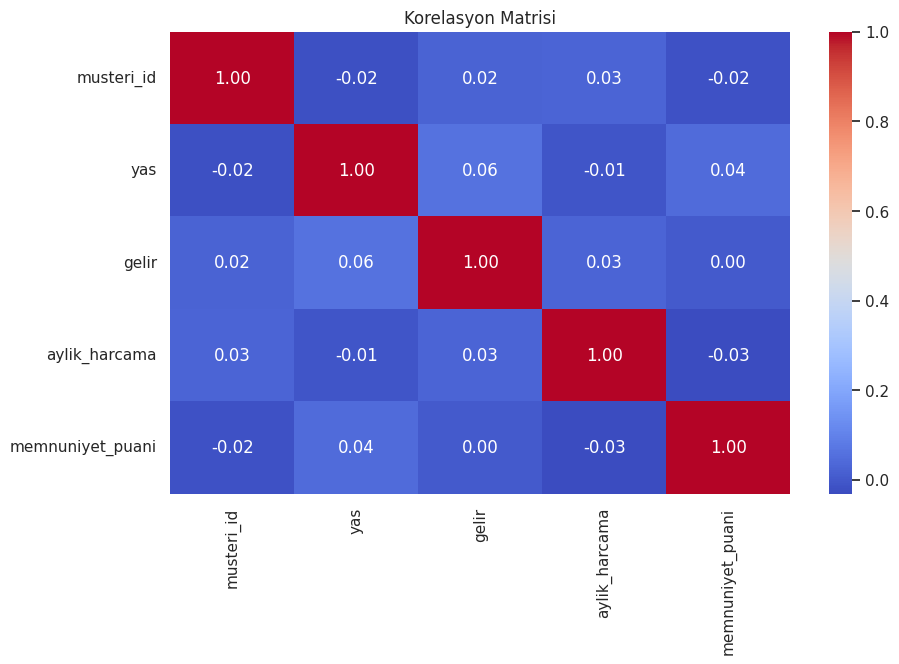

In [ ]:
#heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(
    korelasyon,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasyon Matrisi")
plt.show()